In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [3]:

try:
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
except: pass
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 1. 데이터 로딩 및 파생변수 생성
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## K-means

### Cell 1: 데이터 로드

In [6]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)
df_clean = df.dropna().copy()

# 2. 파생 변수 생성
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]

for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']
df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 2. 군집화용 피처 설정
#cluster_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
cluster_cols =  temp_cols #+ ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
#cluster_cols = [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric'] + ['Tool_current']
X_cluster = df_clean[cluster_cols]

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"군집화에 사용된 피처 개수: {len(cluster_cols)}개")

군집화에 사용된 피처 개수: 6개


### Cell 2: 최적의 K 찾기 (Elbow Method & Silhouette Score)

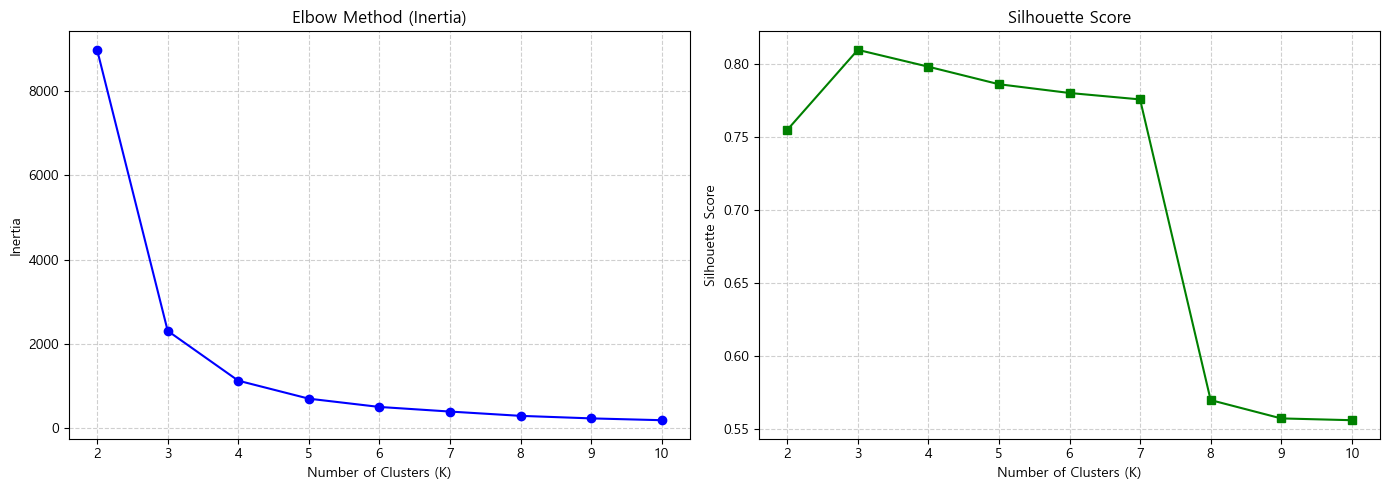


[K값별 실루엣 점수]
  K= 2 → Silhouette = 0.7550
  K= 3 → Silhouette = 0.8099
  K= 4 → Silhouette = 0.7983
  K= 5 → Silhouette = 0.7863
  K= 6 → Silhouette = 0.7803
  K= 7 → Silhouette = 0.7759
  K= 8 → Silhouette = 0.5697
  K= 9 → Silhouette = 0.5571
  K=10 → Silhouette = 0.5559


In [5]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method (Inertia)
axes[0].plot(K_range, inertia, marker='o', linestyle='-', color='b')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Silhouette Score
axes[1].plot(K_range, sil_scores, marker='s', linestyle='-', color='g')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
# 결과 요약 출력
print("\n[K값별 실루엣 점수]")
for k, s in zip(K_range, sil_scores):
    print(f"  K={k:2d} → Silhouette = {s:.4f}")

### Cell 3: K=3 으로 최종 군집화 및 결과 매핑

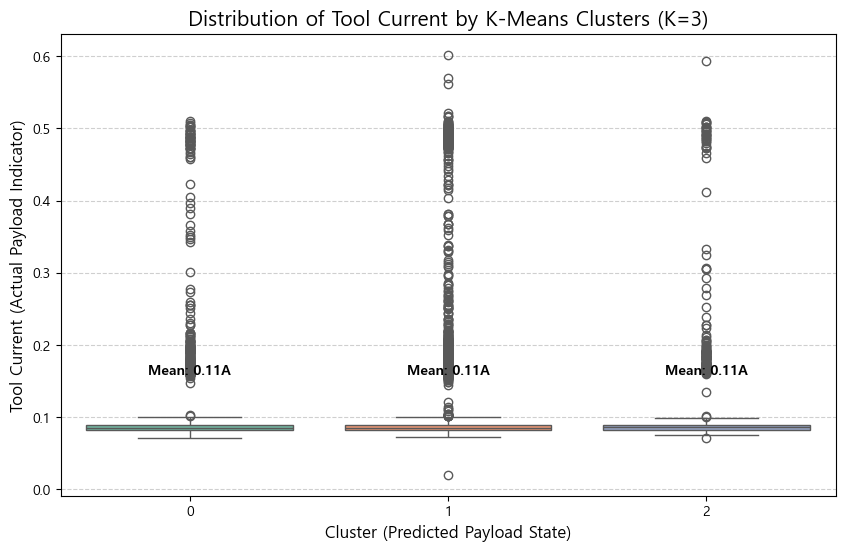

In [6]:
# K=3으로 최종 학습
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 군집 번호를 하중이 작은 순서대로(0, 1, 2) 예쁘게 재정렬하기 위한 작업
cluster_mapping = df_clean.groupby('Cluster')['Tool_current'].mean().sort_values().index
remap_dict = {old_id: new_id for new_id, old_id in enumerate(cluster_mapping)}
df_clean['Cluster'] = df_clean['Cluster'].map(remap_dict)

# 시각화 검증
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Tool_current', data=df_clean, palette='Set2')
plt.title('Distribution of Tool Current by K-Means Clusters (K=3)', fontsize=15)
plt.xlabel('Cluster (Predicted Payload State)', fontsize=12)
plt.ylabel('Tool Current (Actual Payload Indicator)', fontsize=12)

# 각 군집별 Tool_current 평균값 표시
means = df_clean.groupby('Cluster')['Tool_current'].mean()
for i, mean_val in enumerate(means):
    plt.text(i, mean_val + 0.05, f'Mean: {mean_val:.2f}A', ha='center', fontweight='bold', color='black')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

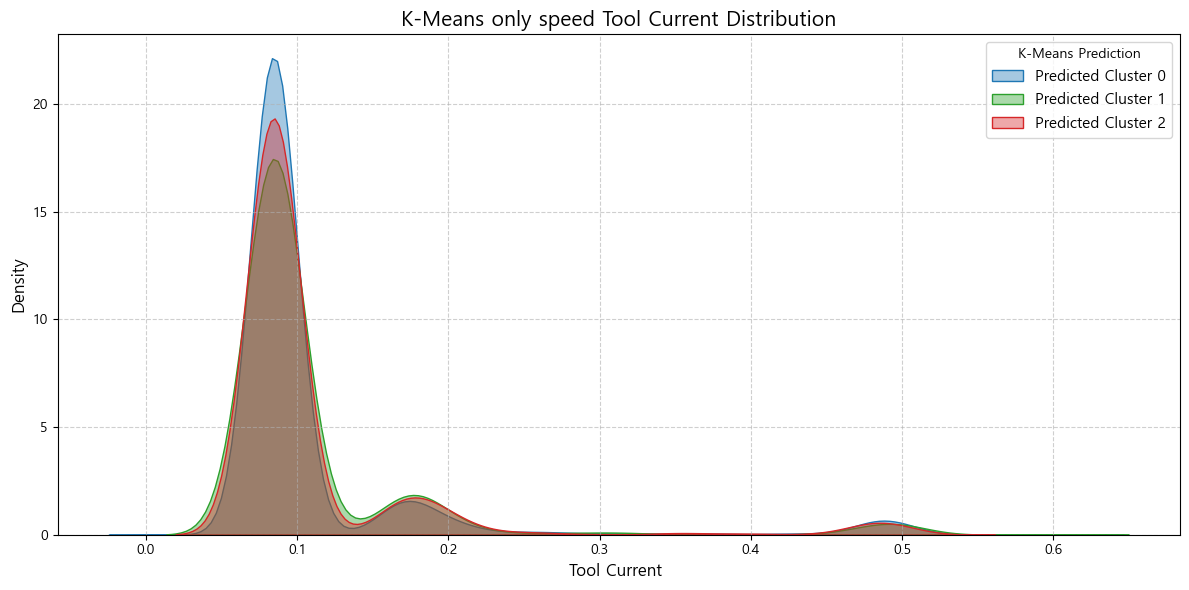


[군집별 Tool_current 평균값]
  Cluster 0: Mean Tool_current = 0.11A
  Cluster 1: Mean Tool_current = 0.11A
  Cluster 2: Mean Tool_current = 0.11A


In [7]:
# K=3으로 최종 학습
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(12, 6))

# 군집별로 색상을 다르게 하여 겹쳐 그리기
colors = ['#1f77b4', '#2ca02c', '#d62728'] # 파랑, 초록, 빨강
for cluster_id, color in zip(sorted(df_clean['Cluster'].unique()), colors):
    sns.kdeplot(
        data=df_clean[df_clean['Cluster'] == cluster_id], 
        x='Tool_current', 
        fill=True, 
        color=color,
        alpha=0.4,
        label=f'Predicted Cluster {cluster_id}'
    )

plt.title('K-Means only speed Tool Current Distribution', fontsize=15)
plt.xlabel('Tool Current ', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='K-Means Prediction', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# 군집별 Tool_current 평균값 표시
cluster_means = df_clean.groupby('Cluster')['Tool_current'].mean()
print("\n[군집별 Tool_current 평균값]")
for cluster_id, mean_val in cluster_means.items():
    print(f"  Cluster {cluster_id}: Mean Tool_current = {mean_val:.2f}A")

  K-Means (K=3) 피처 조합별 군집 성능 & 하중 역추적 일치율 비교


,피처 조합,변수 개수,실루엣 점수 (Clustering Quality),ARI (하중 일치율)
0,① Tool_current Only,1,0.9248,1.0000
1,② Current (6개),6,0.3864,-0.0830
2,③ Current + Speed (12개),12,0.3606,-0.1248
3,④ Current + Power (13개),13,0.4150,-0.1026
4,⑤ All Features (19개),19,0.4150,-0.1209


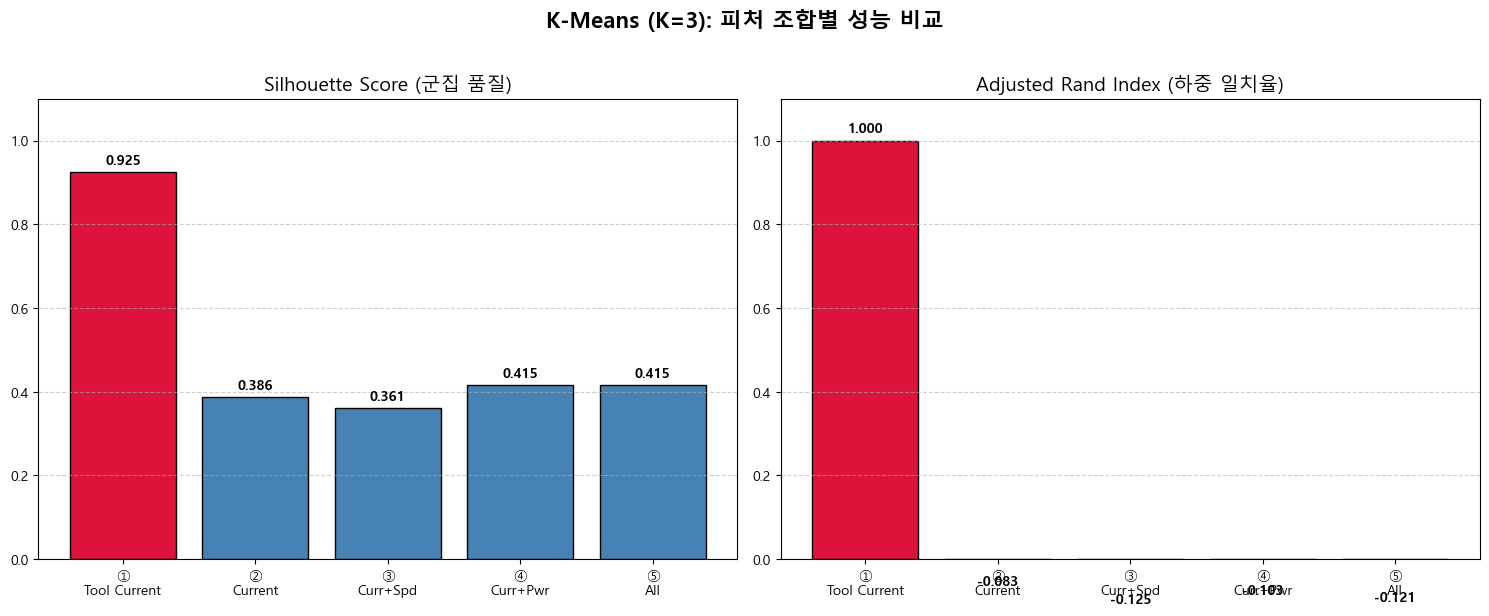

In [9]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

# ==========================================
# [정답 군집 생성] Tool_current 단독 기준 Baseline 라벨
# ==========================================
X_tc = df_clean[['Tool_current']].values
tc_scaler = StandardScaler()
X_tc_scaled = tc_scaler.fit_transform(X_tc)
km_baseline = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels_baseline = km_baseline.fit_predict(X_tc_scaled)

# ==========================================
# [실험] 피처 조합별 K-Means (K=3) 성능 비교
# ==========================================
feature_sets = {
    '① Tool_current Only': ['Tool_current'],
    '② Current (6개)': current_cols,
    '③ Current + Speed (12개)': current_cols + speed_cols,
    '④ Current + Power (13개)': current_cols + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric'],
    '⑤ All Features (19개)': current_cols + speed_cols + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric'],
}

comparison = []

for name, cols in feature_sets.items():
    X_temp = df_clean[cols].values
    sc = StandardScaler()
    X_temp_scaled = sc.fit_transform(X_temp)
    
    km = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_temp_scaled)
    
    # 표준 실루엣 점수 (학습 공간 기준)
    sil = silhouette_score(X_temp_scaled, labels)
    
    # ARI: Baseline 군집(정답)과의 일치율
    ari = adjusted_rand_score(labels_baseline, labels)
    
    comparison.append({
        '피처 조합': name,
        '변수 개수': len(cols),
        '실루엣 점수 (Clustering Quality)': round(sil, 4),
        'ARI (하중 일치율)': round(ari, 4),
    })

df_comp = pd.DataFrame(comparison)

print("="*70)
print("  K-Means (K=3) 피처 조합별 군집 성능 & 하중 역추적 일치율 비교")
print("="*70)
display(df_comp)

# ==========================================
# 시각화 (PPT/보고서 캡처용)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x_labels = ['①\nTool Current', '②\nCurrent', '③\nCurr+Spd', '④\nCurr+Pwr', '⑤\nAll']
colors = ['crimson'] + ['steelblue'] * 4

# 좌측: 실루엣 점수
axes[0].bar(x_labels, df_comp['실루엣 점수 (Clustering Quality)'], color=colors, edgecolor='black')
for i, v in enumerate(df_comp['실루엣 점수 (Clustering Quality)']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].set_title('Silhouette Score (군집 품질)', fontsize=14)
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# 우측: ARI (하중 일치율)
axes[1].bar(x_labels, df_comp['ARI (하중 일치율)'], color=colors, edgecolor='black')
for i, v in enumerate(df_comp['ARI (하중 일치율)']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].set_title('Adjusted Rand Index (하중 일치율)', fontsize=14)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('K-Means (K=3): 피처 조합별 성능 비교', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()